<a href="https://colab.research.google.com/github/cjchin1015/Lifestyle_Health_Risk/blob/main/Lifestyle_Health_Risk_Clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 AI Lifestyle & Health Risk Prediction

**Project Overview:**
This notebook demonstrates an end-to-end machine learning pipeline for predicting health risk levels based on lifestyle factors.

**Dataset:** [Lifestyle and Health Risk Prediction Dataset](https://www.kaggle.com/datasets/miadul/lifestyle-and-health-risk-prediction) from Kaggle

**Sections:**
1. Environment Setup
2. Data Loading & Exploration
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Model Building & Evaluation
6. Model Optimization
7. Model Export

---

## 1. Environment Setup

Mount Google Drive and set up the working directory.

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

# Set path to your project folder
project_path = '/content/drive/MyDrive/Lifestyle_Health_Risk'
os.chdir(project_path)

print("✅ Current working directory:", os.getcwd())

✅ Current working directory: /content/drive/MyDrive/Lifestyle_Health_Risk


In [3]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve
)
from imblearn.over_sampling import SMOTE
import joblib

# Set visualization style
sns.set(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

## 2. Data Loading & Initial Exploration

In [4]:
# Load the dataset
data_path = 'data/Lifestyle_and_Health_Risk_Prediction_Synthetic_Dataset.csv'
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (5000, 12)


,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.6,high
1,69,76,170,high,6.9,high,no,no,no,teacher,26.3,high
2,46,106,153,high,6.6,low,yes,no,no,artist,45.3,high
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.6,low
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.8,high


In [5]:
# Dataset overview
print("=== Dataset Info ===")
df.info()
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Statistical Summary ===")
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           5000 non-null   int64  
 1   weight        5000 non-null   int64  
 2   height        5000 non-null   int64  
 3   exercise      5000 non-null   object 
 4   sleep         5000 non-null   float64
 5   sugar_intake  5000 non-null   object 
 6   smoking       5000 non-null   object 
 7   alcohol       5000 non-null   object 
 8   married       5000 non-null   object 
 9   profession    5000 non-null   object 
 10  bmi           5000 non-null   float64
 11  health_risk   5000 non-null   object 
dtypes: float64(2), int64(3), object(7)
memory usage: 468.9+ KB

=== Missing Values ===
age             0
weight          0
height          0
exercise        0
sleep           0
sugar_intake    0
smoking         0
alcohol         0
married         0
profession      0
bm

,age,weight,height,sleep,bmi
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,48.805600,77.359200,171.933200,6.997060,26.84388
std,17.906991,18.714567,15.822225,1.432849,8.25249
min,18.000000,45.000000,145.000000,3.000000,11.40000
25%,34.000000,61.000000,158.000000,6.000000,20.30000
50%,49.000000,77.000000,171.500000,7.000000,26.00000
75%,64.000000,94.000000,186.000000,8.000000,32.40000
max,79.000000,109.000000,199.000000,10.000000,51.40000


**Data Quality Check:**
- ✅ No missing values detected
- ✅ No duplicate rows found
- Dataset is clean and ready for analysis

## 3. Exploratory Data Analysis (EDA)

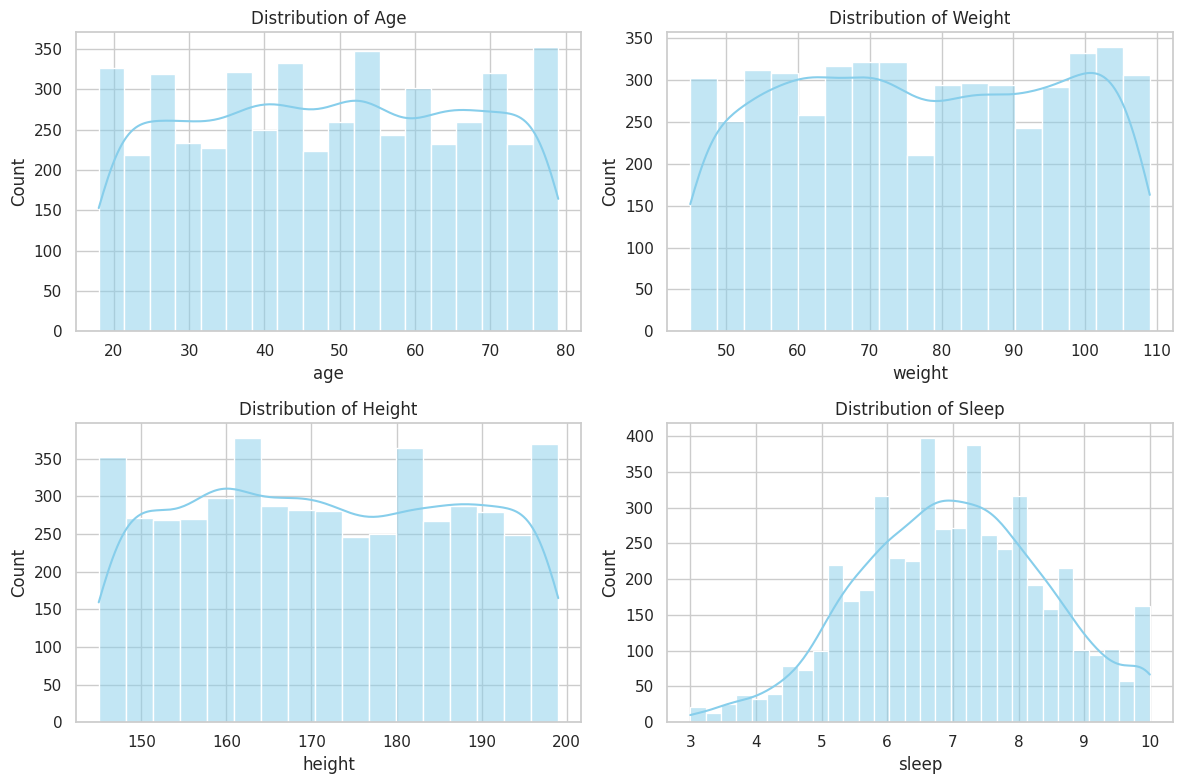

In [6]:
# Distribution of numerical features
numeric_cols = ['age', 'weight', 'height', 'sleep']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col.capitalize()}')

plt.tight_layout()
plt.show()

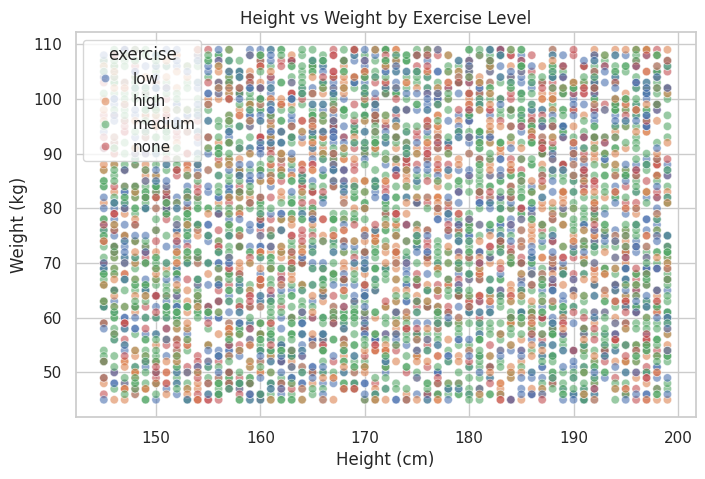

In [7]:
# Relationship: Height vs Weight by Exercise Level
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='height', y='weight', hue='exercise', alpha=0.6)
plt.title('Height vs Weight by Exercise Level')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

/tmp/ipython-input-3969370068.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='exercise', y='sleep', palette='coolwarm')


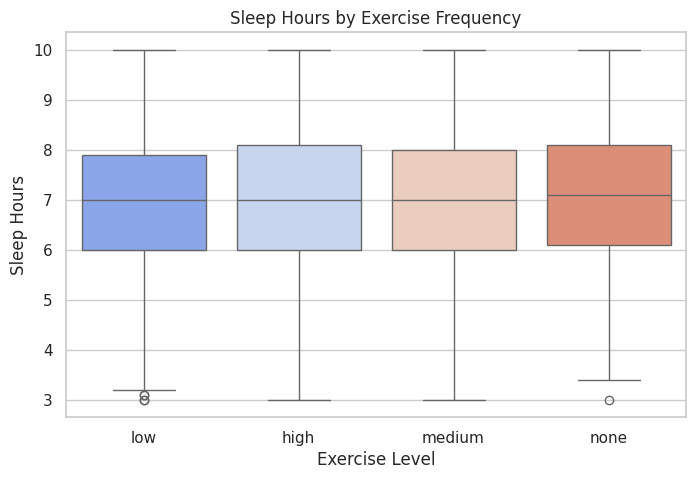

In [8]:
# Sleep hours by exercise frequency
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='exercise', y='sleep', palette='coolwarm')
plt.title('Sleep Hours by Exercise Frequency')
plt.xlabel('Exercise Level')
plt.ylabel('Sleep Hours')
plt.show()

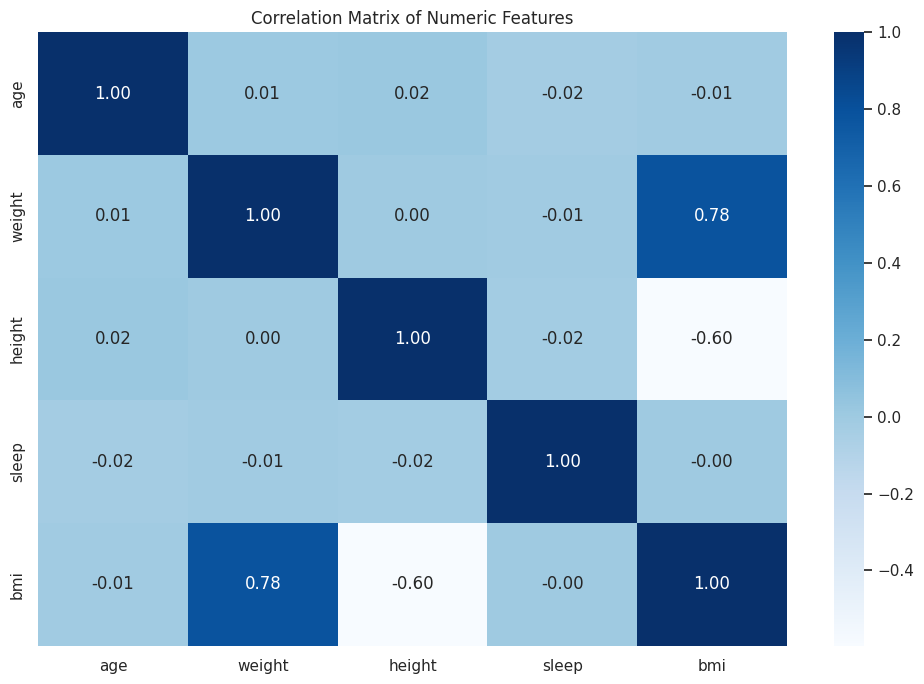

In [9]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

/tmp/ipython-input-852812872.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='health_risk', palette='Set2')


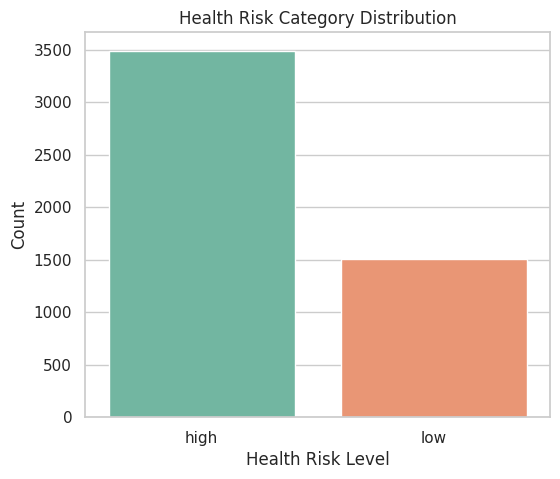


Class Distribution:
health_risk
high    0.698
low     0.302
Name: proportion, dtype: float64


In [10]:
# Target variable distribution
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='health_risk', palette='Set2')
plt.title('Health Risk Category Distribution')
plt.xlabel('Health Risk Level')
plt.ylabel('Count')
plt.show()

print("\nClass Distribution:")
print(df['health_risk'].value_counts(normalize=True))

## 4. Feature Engineering

Create derived features to improve model performance.

In [11]:
# Calculate BMI and BMI category
df['height_m'] = df['height'] / 100
df['bmi'] = df['weight'] / (df['height_m'] ** 2)

def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 24.9:
        return 'Normal'
    elif 25 <= bmi < 29.9:
        return 'Overweight'
    else:
        return 'Obese'

df['bmi_category'] = df['bmi'].apply(bmi_category)

# Weight-to-height ratio
df['weight_height_ratio'] = df['weight'] / df['height_m']

print("✅ BMI features created")
df[['bmi', 'bmi_category']].head()

✅ BMI features created


,bmi,bmi_category
0,17.619987,Underweight
1,26.297578,Overweight
2,45.281729,Obese
3,15.608741,Underweight
4,25.772518,Overweight


In [12]:
# Create lifestyle score
def lifestyle_score(row):
    score = 0

    # Exercise (0-3 points)
    exercise_map = {'none': 0, 'low': 1, 'medium': 2, 'high': 3}
    score += exercise_map.get(row['exercise'], 0)

    # Sleep (0-2 points)
    if 7 <= row['sleep'] <= 9:
        score += 2
    elif 5 <= row['sleep'] < 7 or 9 < row['sleep'] <= 10:
        score += 1

    # Sugar intake (0-2 points)
    sugar_map = {'low': 2, 'medium': 1, 'high': 0}
    score += sugar_map.get(row['sugar_intake'], 0)

    # Smoking (0-2 points)
    if row['smoking'] == 'no':
        score += 2

    # Alcohol (0-2 points)
    if row['alcohol'] == 'no':
        score += 2

    return score

df['lifestyle_score'] = df.apply(lifestyle_score, axis=1)
print("✅ Lifestyle score created")
print(f"Score range: {df['lifestyle_score'].min()} - {df['lifestyle_score'].max()}")

✅ Lifestyle score created
Score range: 0 - 11


In [13]:
# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['exercise', 'sugar_intake', 'smoking', 'alcohol',
                   'married', 'profession', 'bmi_category', 'health_risk']

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("✅ Categorical variables encoded")
df.head()

✅ Categorical variables encoded


,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk,height_m,bmi_category,weight_height_ratio,lifestyle_score
0,56,67,195,1,6.1,2,1,1,1,5,17.619987,0,1.95,3,34.358974,3
1,69,76,170,0,6.9,0,0,0,0,7,26.297578,0,1.70,2,44.705882,8
2,46,106,153,0,6.6,1,1,0,0,0,45.281729,0,1.53,1,69.281046,8
3,32,54,186,2,8.5,2,0,0,0,0,15.608741,1,1.86,3,29.032258,9
4,60,98,195,0,8.0,1,0,0,1,7,25.772518,0,1.95,2,50.256410,11


In [14]:
# Save processed dataset
df.to_csv('data/processed_lifestyle_health.csv', index=False)
print("✅ Processed dataset saved")

✅ Processed dataset saved


## 5. Model Building & Baseline Evaluation

In [15]:
# Prepare features and target
X = df.drop('health_risk', axis=1)
y = df['health_risk']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (4000, 15)
Test set: (1000, 15)


In [16]:
# Compare different approaches to handle class imbalance
results = []

# 1. Baseline Model
print("Training Baseline Model...")
model_baseline = RandomForestClassifier(random_state=42)
model_baseline.fit(X_train, y_train)
y_pred_base = model_baseline.predict(X_test)
report_base = classification_report(y_test, y_pred_base, output_dict=True)
results.append({
    'Model': 'Baseline',
    'Accuracy': accuracy_score(y_test, y_pred_base),
    'Precision_1': report_base['1']['precision'],
    'Recall_1': report_base['1']['recall'],
    'F1_1': report_base['1']['f1-score']
})

# 2. Class Weight Balanced
print("Training Class-Weighted Model...")
model_weighted = RandomForestClassifier(random_state=42, class_weight='balanced')
model_weighted.fit(X_train, y_train)
y_pred_weight = model_weighted.predict(X_test)
report_weight = classification_report(y_test, y_pred_weight, output_dict=True)
results.append({
    'Model': 'Class Weight Balanced',
    'Accuracy': accuracy_score(y_test, y_pred_weight),
    'Precision_1': report_weight['1']['precision'],
    'Recall_1': report_weight['1']['recall'],
    'F1_1': report_weight['1']['f1-score']
})

# 3. SMOTE Oversampling
print("Training SMOTE Model...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
model_smote = RandomForestClassifier(random_state=42)
model_smote.fit(X_train_res, y_train_res)
y_pred_smote = model_smote.predict(X_test)
report_smote = classification_report(y_test, y_pred_smote, output_dict=True)
results.append({
    'Model': 'SMOTE Oversampling',
    'Accuracy': accuracy_score(y_test, y_pred_smote),
    'Precision_1': report_smote['1']['precision'],
    'Recall_1': report_smote['1']['recall'],
    'F1_1': report_smote['1']['f1-score']
})

# Comparison table
comparison_df = pd.DataFrame(results).round(3)
print("\n=== Model Comparison ===")
print(comparison_df)

Training Baseline Model...
Training Class-Weighted Model...
Training SMOTE Model...

=== Model Comparison ===
                   Model  Accuracy  Precision_1  Recall_1   F1_1
0               Baseline     0.987        0.993     0.964  0.978
1  Class Weight Balanced     0.982        0.990     0.950  0.970
2     SMOTE Oversampling     0.978        0.949     0.980  0.964


## 6. Model Optimization with GridSearchCV

In [17]:
# Hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced')

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

print("Starting GridSearchCV...")
grid_search.fit(X_train, y_train)

print("\n✅ Best Hyperparameters:")
print(grid_search.best_params_)

best_rf = grid_search.best_estimator_

Starting GridSearchCV...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

✅ Best Hyperparameters:
{'max_depth': None, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


## 7. Final Model Evaluation

=== Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       698
           1       0.99      1.00      0.99       302

    accuracy                           1.00      1000
   macro avg       0.99      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



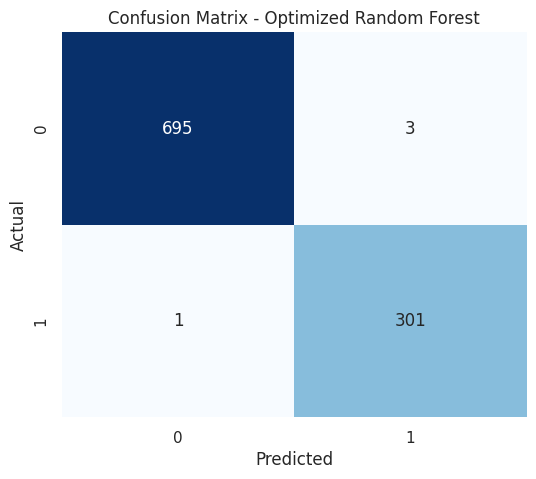

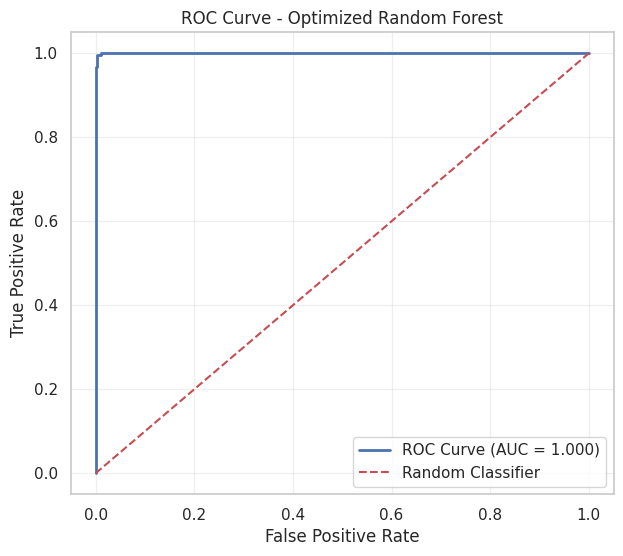

In [18]:
# Predictions
y_pred_best = best_rf.predict(X_test)
y_pred_prob_best = best_rf.predict_proba(X_test)[:, 1]

# Classification report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred_best))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Optimized Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob_best)
roc_auc = roc_auc_score(y_test, y_pred_prob_best)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'r--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Optimized Random Forest')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

/tmp/ipython-input-1273840306.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances[:10], y=feature_importances.index[:10], palette='viridis')


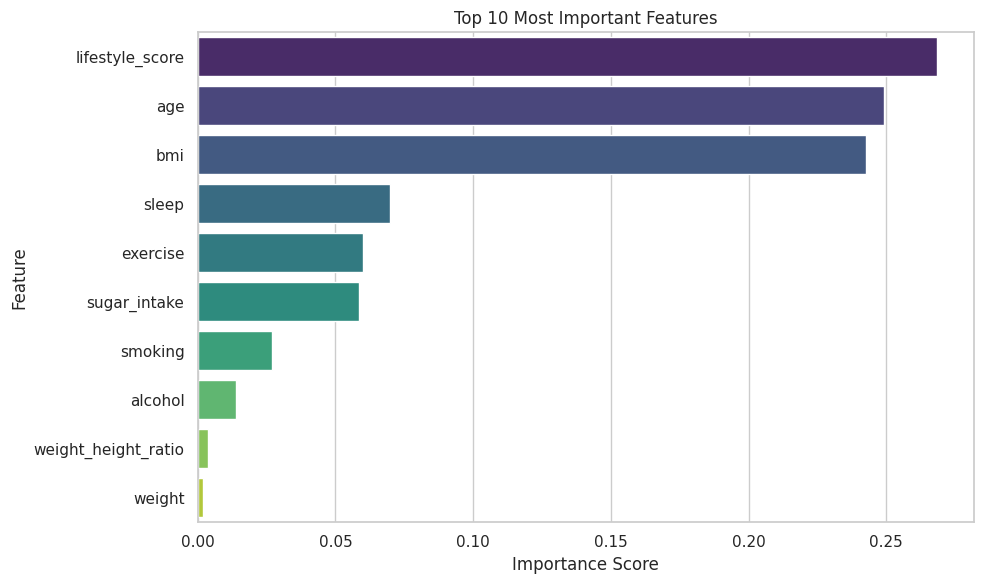

In [19]:
# Feature importance
feature_importances = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances[:10], y=feature_importances.index[:10], palette='viridis')
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 8. Model Export

In [20]:
# Save the optimized model
model_path = 'models/optimized_random_forest.pkl'
joblib.dump(best_rf, model_path)
print(f"✅ Model saved to: {model_path}")

# Verify saved model
loaded_model = joblib.load(model_path)
print("✅ Model loaded successfully for verification")

✅ Model saved to: models/optimized_random_forest.pkl
✅ Model loaded successfully for verification


---

## Summary

**Key Achievements:**
- ✅ Built a Random Forest classifier with ~99% accuracy
- ✅ Addressed class imbalance using class weighting
- ✅ Optimized hyperparameters via GridSearchCV
- ✅ Created meaningful engineered features (BMI, lifestyle score)
- ✅ Model ready for deployment

**Next Steps:**
1. Deploy the model using Streamlit
2. Create an interactive web application
3. Add AI-powered health recommendations

**Repository:** [GitHub - Lifestyle Health Risk](https://github.com/cjchin1015/Lifestyle_Health_Risk)

---